In [1]:
import numpy as np
import gvar as gv
import h5py
import pickle
import matplotlib.pyplot as plt
from cycler import cycler

In [2]:
def compute_exp_dEt_jkn(
    M_fit_jkn:  np.ndarray,
    nmax:    int,
    ns:     int,
    timeslices: np.ndarray
) -> np.ndarray:
    """
    E(p) = sqrt(p^2 + M^2)
    where p^2 = (2*pi/Ns)^2 * n^2
    dE(p) = sqrt(p^2 + M^2)
    """
    p_squared = (2.0 * np.pi / ns) ** 2 * nmax
    dE_jkn = np.sqrt(p_squared + M_fit_jkn ** 2) - M_fit_jkn
    return np.exp(dE_jkn[:, None] * timeslices[None, :])

In [3]:
ensemble           = "D251"
nmax_values        = [1, 2, 3, 4, 5, 6, 8]

ns = 64

# ---- load data ----
R_jkn_per_mom = {}
for nmax in nmax_values:
    path = f"/hdd/data/ensemble_data/{ensemble}/c2pt/{ensemble}_c2pt_jkn.h5"
    with h5py.File(path, "r") as file:
        for nmax in nmax_values:
            R_jkn_per_mom[nmax] = file[f"/c2pt_ratio/nsquare_{nmax}"][()]

    with open(
        f"/hdd/data/fit_results/{ensemble}/nucleon_energies/"
        f"{ensemble}_E0_jkn_mom00_tzero03.pkl", "rb"
    ) as f:
        M_fit_jkn = pickle.load(f)

In [4]:
R_jkn = R_jkn_per_mom[1]
print(R_jkn.shape)
print(R_jkn)

(2012, 128)
[[0.80349325 0.7753481  0.75710992 ... 0.81741754 0.81317406 0.81589404]
 [0.80349446 0.77535125 0.75711304 ... 0.81742056 0.81317714 0.81589593]
 [0.80349335 0.7753491  0.75711139 ... 0.81742158 0.8131768  0.81589489]
 ...
 [0.80349406 0.77534731 0.75710749 ... 0.81742208 0.81317694 0.81589553]
 [0.80349271 0.77535048 0.75710845 ... 0.8174162  0.8131741  0.8158946 ]
 [0.80349281 0.77534827 0.7571123  ... 0.81741723 0.81317522 0.81589299]]


In [5]:
plt.rcParams.update({
    "font.size": 18,
    "font.family": "computer modern",
    "text.usetex": True,
    "figure.dpi": 200,
    "axes.prop_cycle":
        cycler(color=[
            "#1E6EF4",
            "#ff8d28",
            "#34C759",
            "#E7124D",
        ])
})
blue       = "#1E6EF4"
markersize = 8
capsize    = 6
linewidth  = 2

In [6]:
# HARDCODE FOR NOW
fit_results = {
    1: {"fit_range": [14, 44], "B0": gv.gvar("0.76269(42)")},
    2: {"fit_range": [13, 42], "B0": gv.gvar("0.58458(59)")},
    3: {"fit_range": [13, 39], "B0": gv.gvar("0.44983(73)")},
    4: {"fit_range": [13, 36], "B0": gv.gvar("0.34763(78)")},
    5: {"fit_range": [15, 36], "B0": gv.gvar("0.26956(85)")},
    6: {"fit_range": [13, 36], "B0": gv.gvar("0.21001(84)")},
    8: {"fit_range": [15, 29], "B0": gv.gvar("0.12883(90)")},
    }

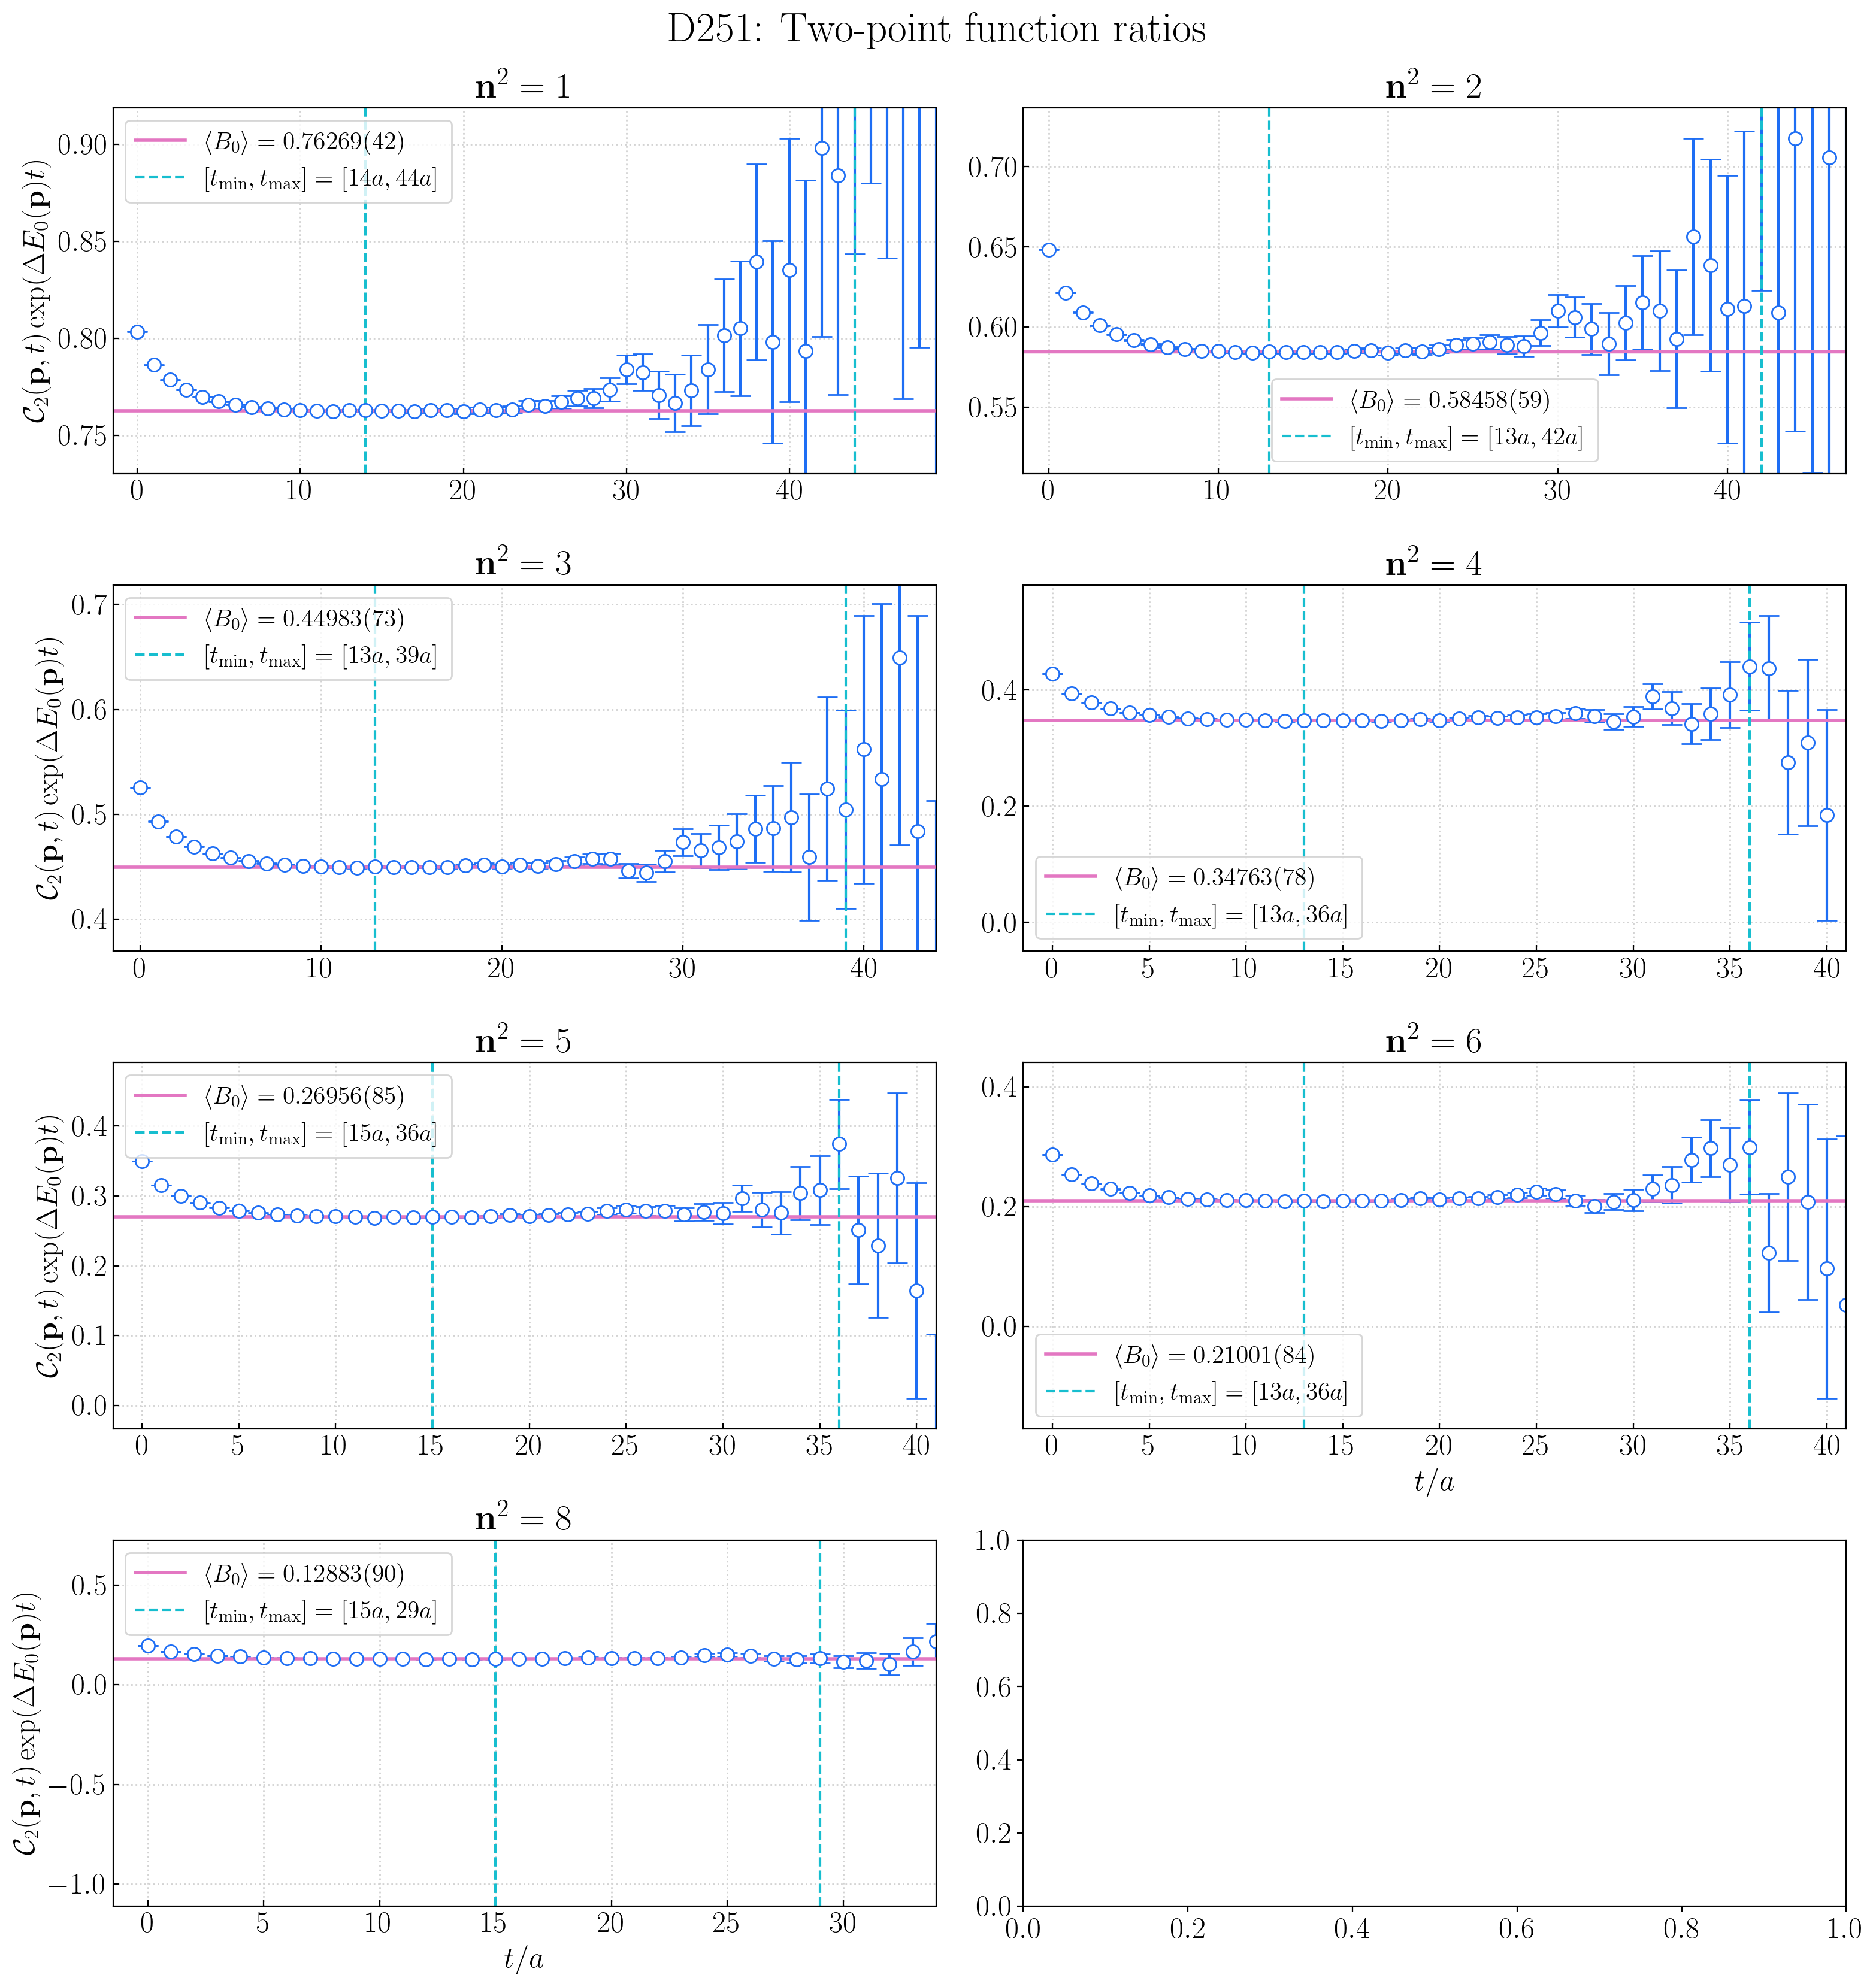

In [7]:
fig, axs = plt.subplots(4, 2, figsize=(16, 17))  # removed sharey=True
axs_flat = axs.flatten()

for i, nmax in enumerate(nmax_values):
    ax   = axs_flat[i]

    R_jkn       = R_jkn_per_mom[nmax]
    n_res, n_t  = R_jkn.shape
    timeslices  = np.arange(n_t)

    R_jkn       = R_jkn * compute_exp_dEt_jkn(M_fit_jkn, nmax, ns, timeslices)
    R_jkn_avg   = np.mean(R_jkn, axis=0)
    R_jkn_err   = np.std(R_jkn, axis=0, ddof=0) * np.sqrt(n_res - 1)

    t_min, t_max = [10, 40] 

    # TWO-POINT FUNCTION RATIO DATA
    ax.errorbar(timeslices, R_jkn_avg, R_jkn_err,
                fmt="o", mfc="white", color=blue,
                markersize=markersize, capsize=capsize)

    # MODEL AVERAGES OF OVERLAP RATIOS
    B0 = fit_results[nmax]["B0"]
    B0_est = gv.mean(B0)
    B0_err = gv.sdev(B0)

    # Compute y-limits from data within [t_min, t_max]
    mask = (timeslices >= t_min) & (timeslices <= t_max)
    y_vis = R_jkn_avg[mask]
    e_vis = R_jkn_err[mask]
    finite = np.isfinite(y_vis) & np.isfinite(e_vis)
    if finite.any():
        ylo = (y_vis[finite] - e_vis[finite]).min()
        yhi = (y_vis[finite] + e_vis[finite]).max()
        pad = 0.1 * (yhi - ylo)
        ax.set_ylim(ylo - pad, yhi + pad)

    ax.axhspan(B0_est - B0_err, B0_est + B0_err,
               color="tab:pink", alpha=0.25)
    ax.axhline(B0_est, color="tab:pink", linewidth=linewidth,
               label=rf"$\langle B_0 \rangle = {B0}$")

    t_min, t_max = fit_results[nmax]["fit_range"]

    # --- fit window markers ---
    ax.axvline(t_min, color="tab:cyan", linestyle="--", linewidth=1.5,
               label=rf"$[t_{{\min}}, t_{{\max}}] = [{t_min}a, {t_max}a]$")
    ax.axvline(t_max, color="tab:cyan", linestyle="--", linewidth=1.5)

    if i >= len(nmax_values) - 2:
        ax.set_xlabel(r"$t/a$")
    if i % 2 == 0:
        ax.set_ylabel(r"$\mathcal{C}_2(\mathbf{p}, t)\exp(\Delta E_0(\mathbf{p})t)$")

    ax.set_xlim(-1.5, t_max + 5)
    ax.legend(fontsize=15)
    ax.set_title(rf"$\mathbf{{n}}^2 = {nmax}$")
    ax.grid(color="lightgrey", linestyle=":", linewidth=1)
    ax.tick_params(direction="in")

fig.suptitle(rf"$\mathrm{{{ensemble}}}$: Two-point function ratios", fontsize=25)
fig.tight_layout(rect=[0, 0, 1, 0.97])

# plt.savefig(f"/home/ck/phd/code/hadrana/plots/{ensemble}_effective_energies.pdf")

fig.tight_layout()
plt.show()